# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: TradingAgents
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\TradingAgents.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\TradingAgents.sqlite
Closed event type id: 178


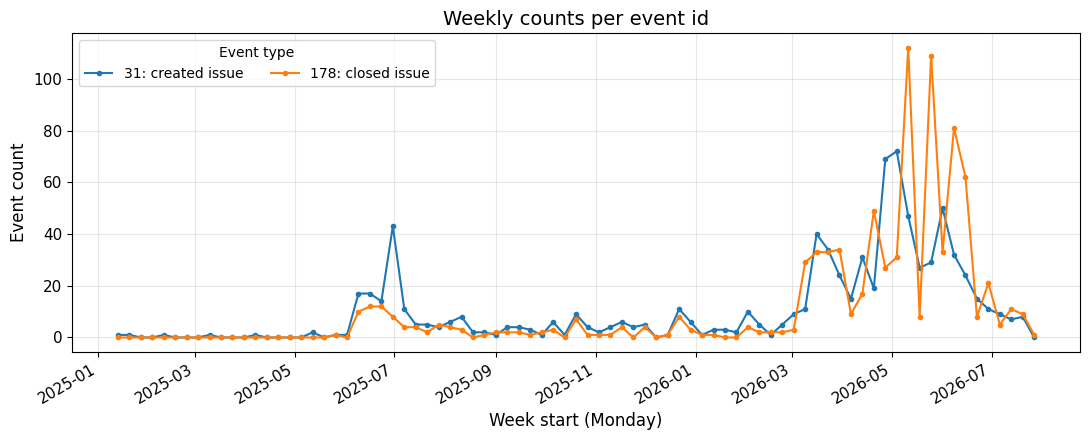

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\weekly_open_closed_summary.csv


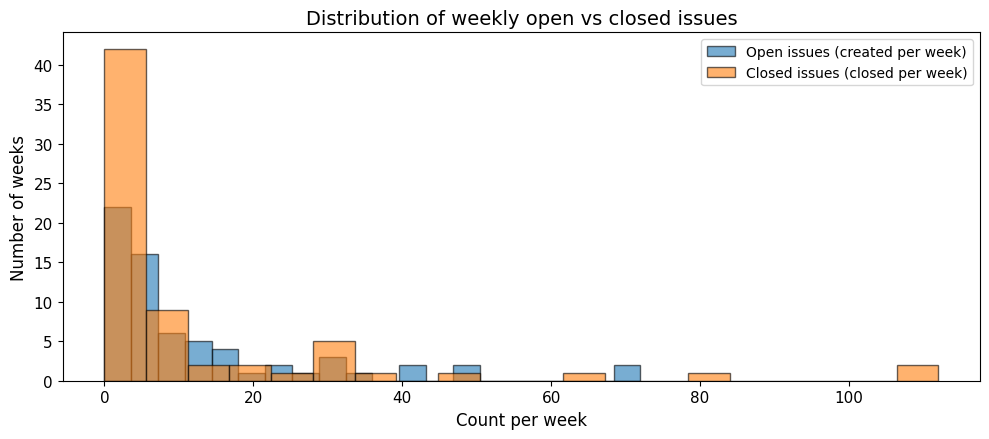

,Open issues (weekly created),Closed issues (weekly closed)
count,67.00,67.00
mean,12.36,12.61
std,15.93,23.18
min,0.00,0.00
25%,2.00,1.00
50%,6.00,3.00
75%,15.00,10.50
max,72.00,112.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("TradingAgents")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [2]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 15 rolling-IQR anomalies for event_type_id=178.
Joined title attribute rows: 845 of 845 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2025-06-09,10,True,high,0.0,0.000,0.000,9,10,P4,documentation,Weekly closures show a near-typical spike (10 ...,rule_based,0.675000,"[closed (#14), closed (#15), closed (#13), clo...","[Initial updates, aaaa, docs: add links to oth..."
1,2025-06-16,12,True,high,0.0,0.000,0.000,12,12,P2,git integration,Weekly closures show a near-typical spike (12 ...,rule_based,0.574792,"[closed (#42), closed (#44), closed (#4), clos...","[Test branch, Merge dev into main branch, Did ..."
2,2025-06-23,12,True,high,13.5,-1.125,1.875,12,12,P2,testing,Weekly closures show a well beyond-typical spi...,rule_based,0.655500,"[closed (#55), closed (#45), closed (#46), clo...","[Cryptocurrency, add i18n to support en/zh, Up..."
3,2026-03-09,29,True,high,11.5,-2.000,6.000,29,29,P2,runtime stability,Weekly closures show a well beyond-typical spi...,rule_based,0.763889,"[closed (#317), closed (#217), closed (#30), c...",[use google gemin-2.5-flash-preview-05-20 erro...
4,2026-03-16,33,True,high,13.5,-2.000,6.000,32,33,P2,documentation,Weekly closures show a well beyond-typical spi...,rule_based,0.647917,"[closed (#386), closed (#381), closed (#273), ...",[fix: Add max_summary_chars param to reduce to...


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2025-06-09,89686
1,2025-06-09,89744
2,2025-06-09,89824
3,2025-06-09,89920
4,2025-06-09,89999


## 4. Anomaly plots


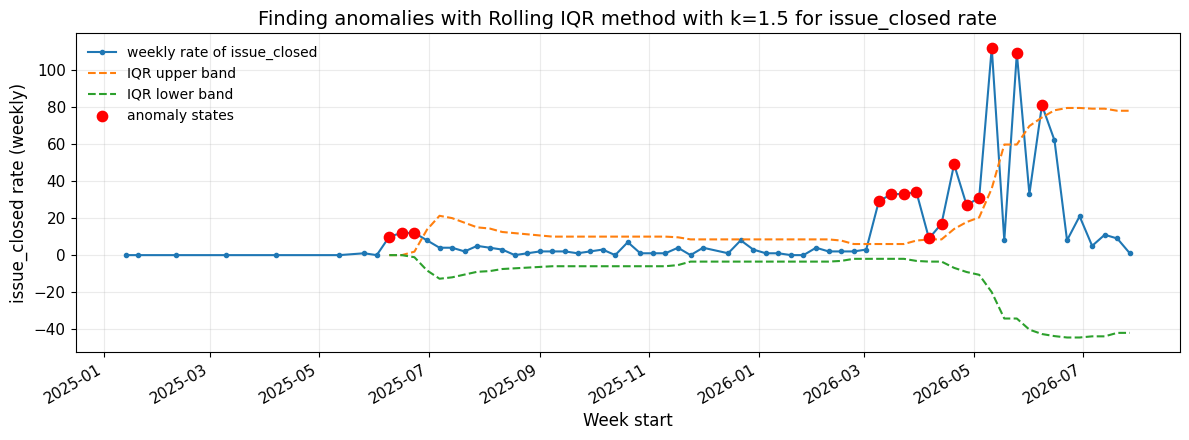

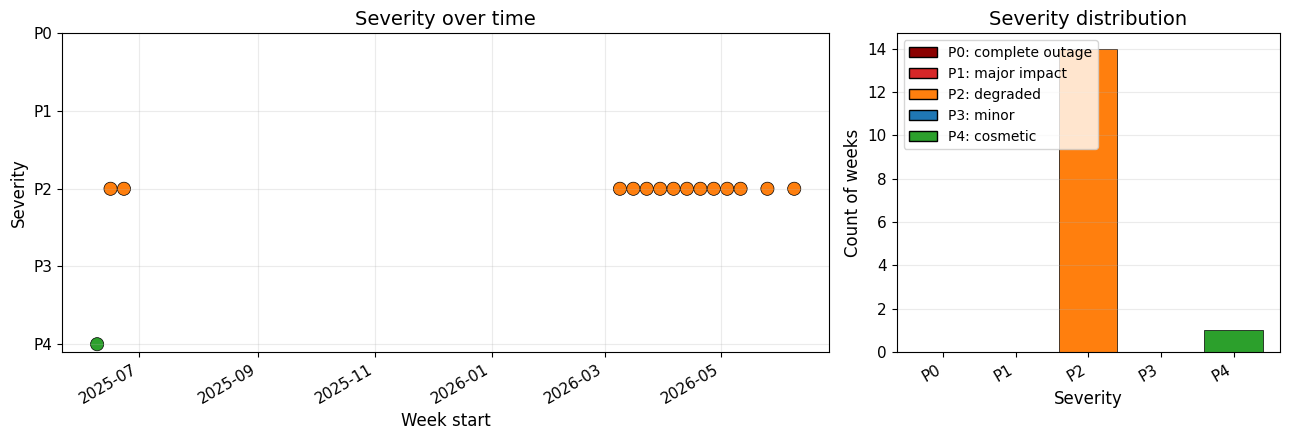

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


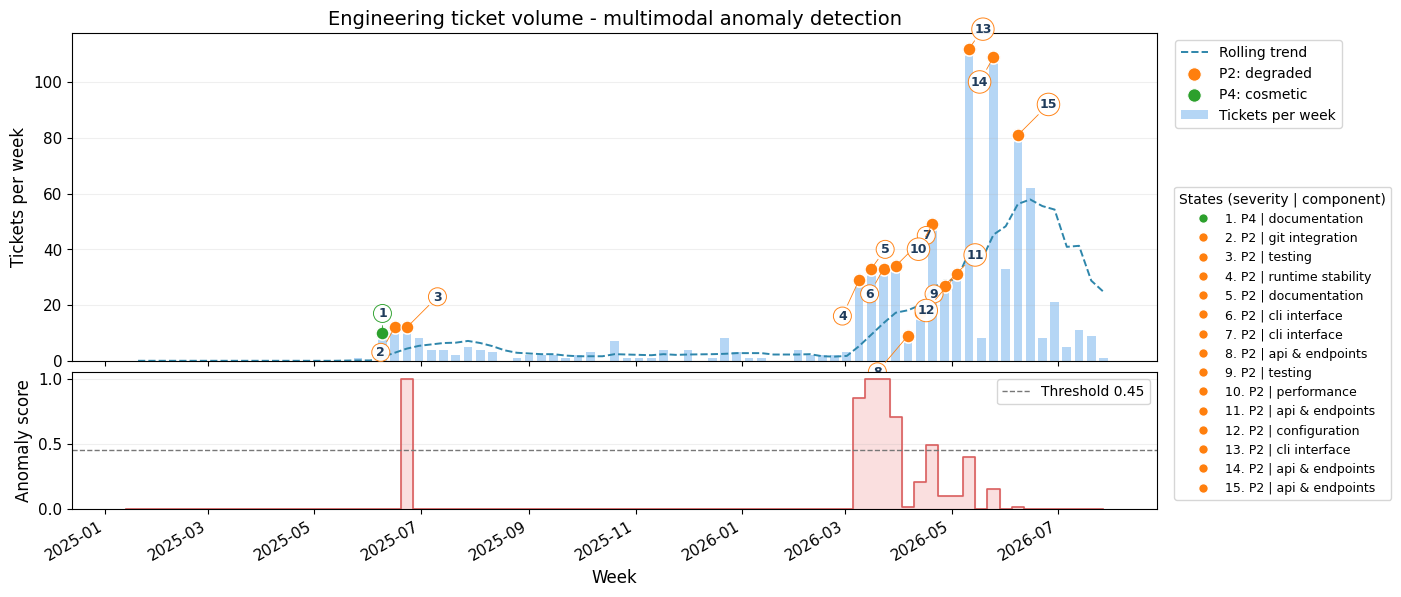

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:503: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


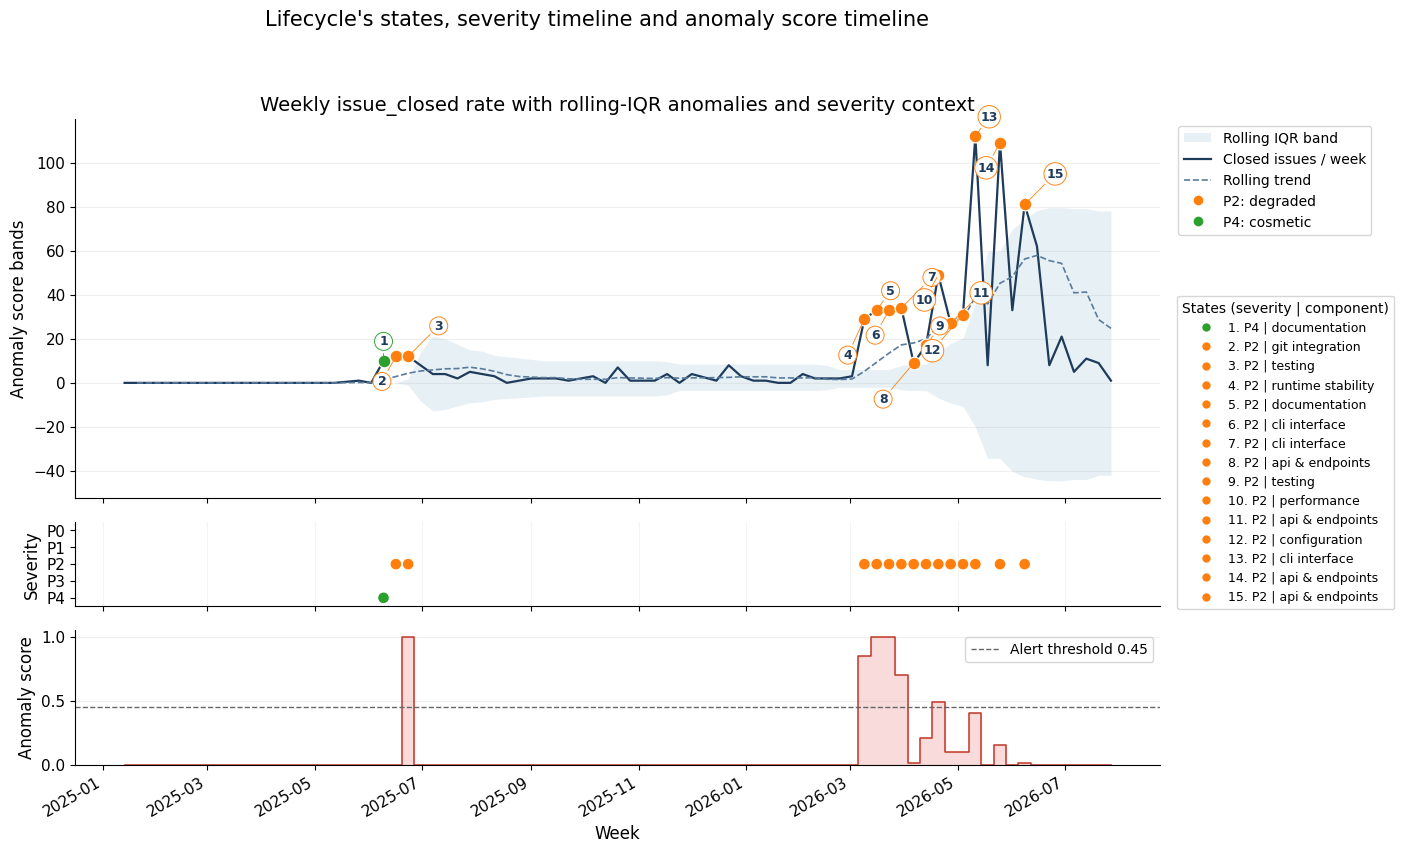

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/TradingAgents')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


commit_context summary: 15 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\commit_context.csv
commit_typeclass_per_week summary: 15 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.199
  bug_fixes     0.183
  tech_debt     0.135
  docs          0.043
  other         0.441

Mean category ratios by anomaly_direction:
  [high] feature_work=0.199  bug_fixes=0.183  tech_debt=0.135  docs=0.043  other=0.441

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\commit_typeclass_per_week.csv


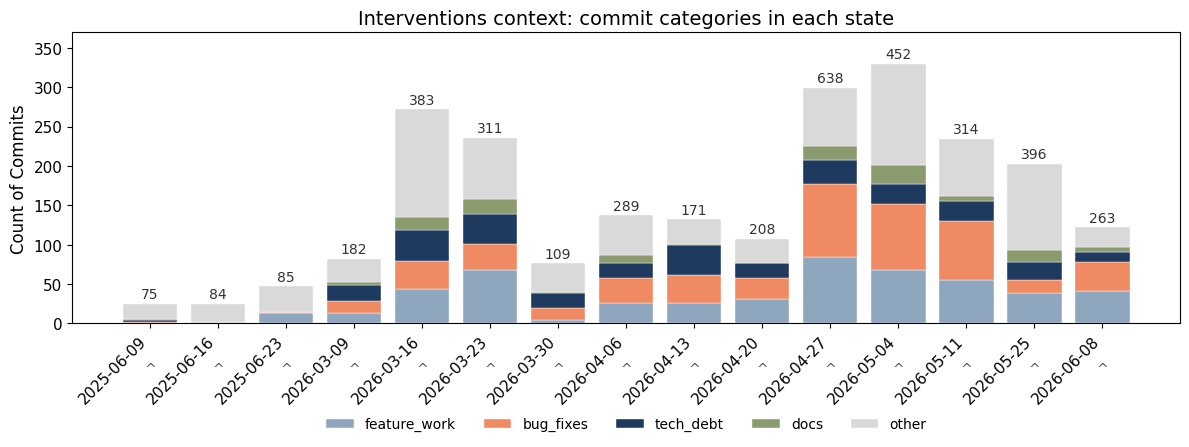

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/TradingAgents')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 14059 events, 828 cases
  case:concept:name  concept:name            time:timestamp
0             11684       created 2026-06-28 21:14:25+00:00
1             11684  unsubscribed 2026-06-29 18:54:45+00:00
2             11684     commented 2026-07-04 15:58:06+00:00
3             11684     commented 2026-07-04 15:58:28+00:00
4             11684        closed 2026-07-05 14:38:38+00:00
5             11684     commented 2026-07-08 01:22:31+00:00
6             11733     committed 2026-06-28 06:18:32+00:00
7             11733     committed 2026-06-28 06:29:47+00:00
8             11733     committed 2026-06-28 06:39:02+00:00
9             11733     committed 2026-06-28 07:21:20+00:00


## 7. Vitalizing subset from anomaly object IDs


In [7]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 9367 rows, 588 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [8]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 213 -> 163 cases | 3766 -> 965 events
Whole: 315 -> 239 cases | 6033 -> 1385 events
Random control (rebuilt): 163 cases | 937 events


## 9. Discovery F1 evaluation on clean logs


In [9]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 94/94 [00:00<00:00, 536.72it/s]


Expected records: 30 | Observed: 30

7) Consolidated results table in clean logs
               log_name         discovery_method  distinct_traces  \
0   random_case_control            alpha_classic               94   
1            vitalizing            alpha_classic               93   
2                 whole            alpha_classic              124   
3   random_case_control       heuristics_dep_0.6               94   
4            vitalizing       heuristics_dep_0.6               93   
5                 whole       heuristics_dep_0.6              124   
6   random_case_control       heuristics_dep_0.7               94   
7            vitalizing       heuristics_dep_0.7               93   
8                 whole       heuristics_dep_0.7              124   
9   random_case_control       heuristics_dep_0.8               94   
10           vitalizing       heuristics_dep_0.8               93   
11                whole       heuristics_dep_0.8              124   
12  random_case_contro

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,94,0.586428,0.610262,0.209068,0.311441,46.0,1.0,1.000000,ok,None
1,vitalizing,alpha_classic,93,0.636250,0.766365,0.248659,0.375486,57.0,6.0,1.000000,ok,None
2,whole,alpha_classic,124,0.637910,0.614343,0.193163,0.293913,43.0,1.0,1.000000,ok,None
3,random_case_control,heuristics_dep_0.6,94,0.453144,0.784135,0.538008,0.638163,325.0,20.0,0.500000,ok,None
4,vitalizing,heuristics_dep_0.6,93,0.472821,0.800063,0.591667,0.680262,318.0,20.0,0.478927,ok,None


## 10. Utility figures


Plotting from 30 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'heuristics_dep_0.8', 'heuristics_dep_0.9', 'inductive_IM', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'inductive_IMf_noise_0.5', 'inductive_IMf_noise_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\TradingAgents\clean_log_f_score_grouped_bars.{png,pdf}


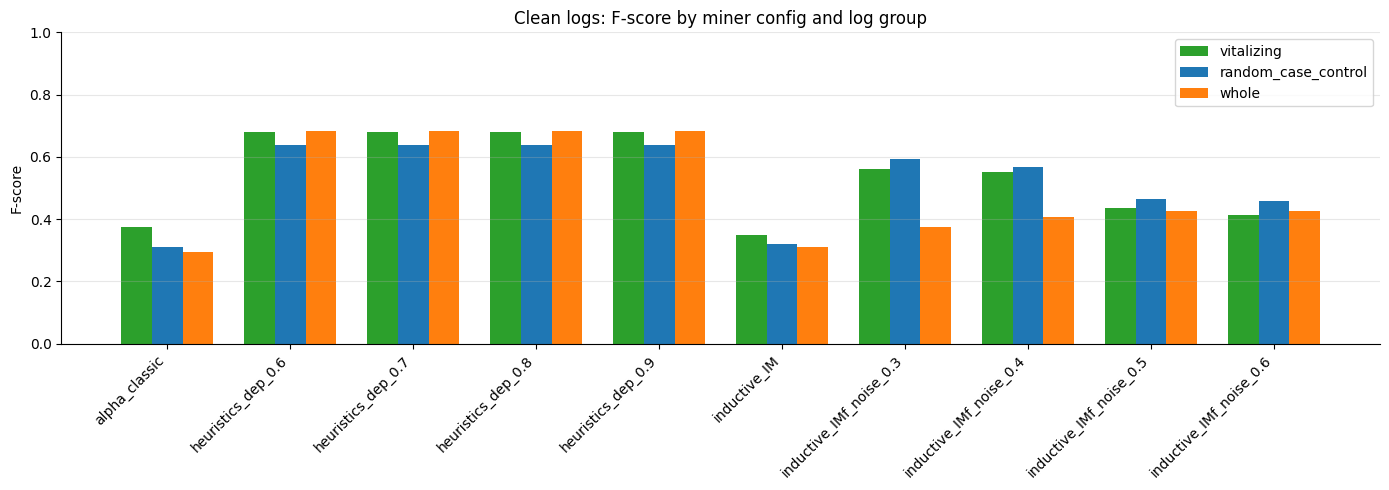

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\TradingAgents\clean_log_fitness_precision.{png,pdf}


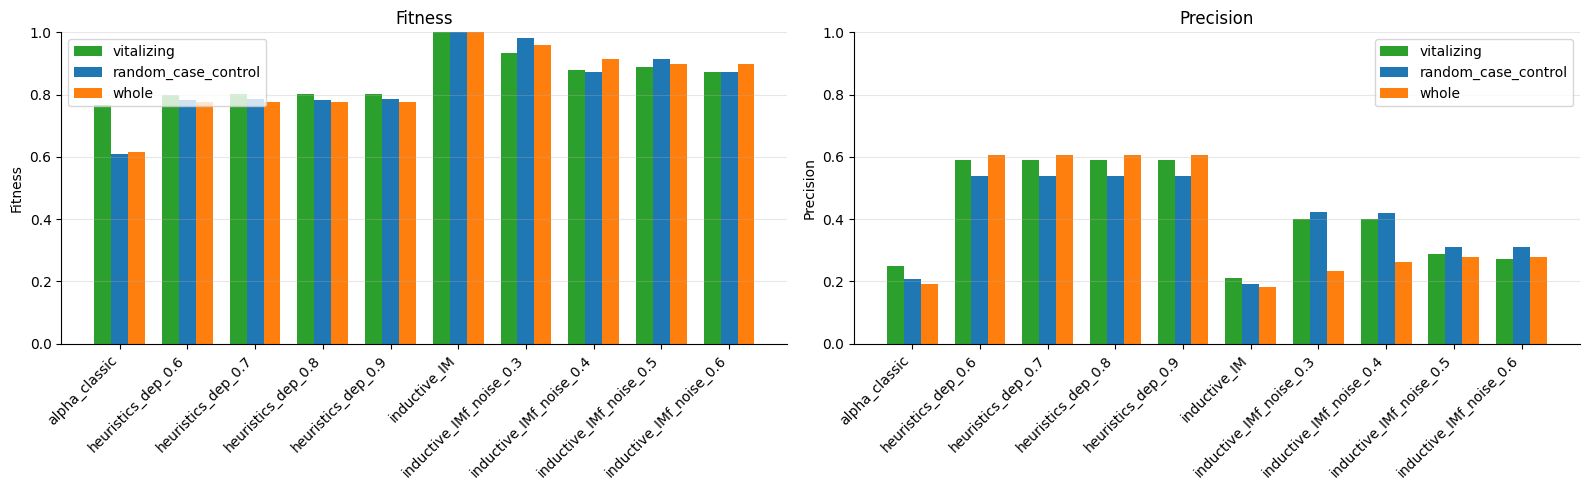

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\TradingAgents\clean_log_complexity.{png,pdf}


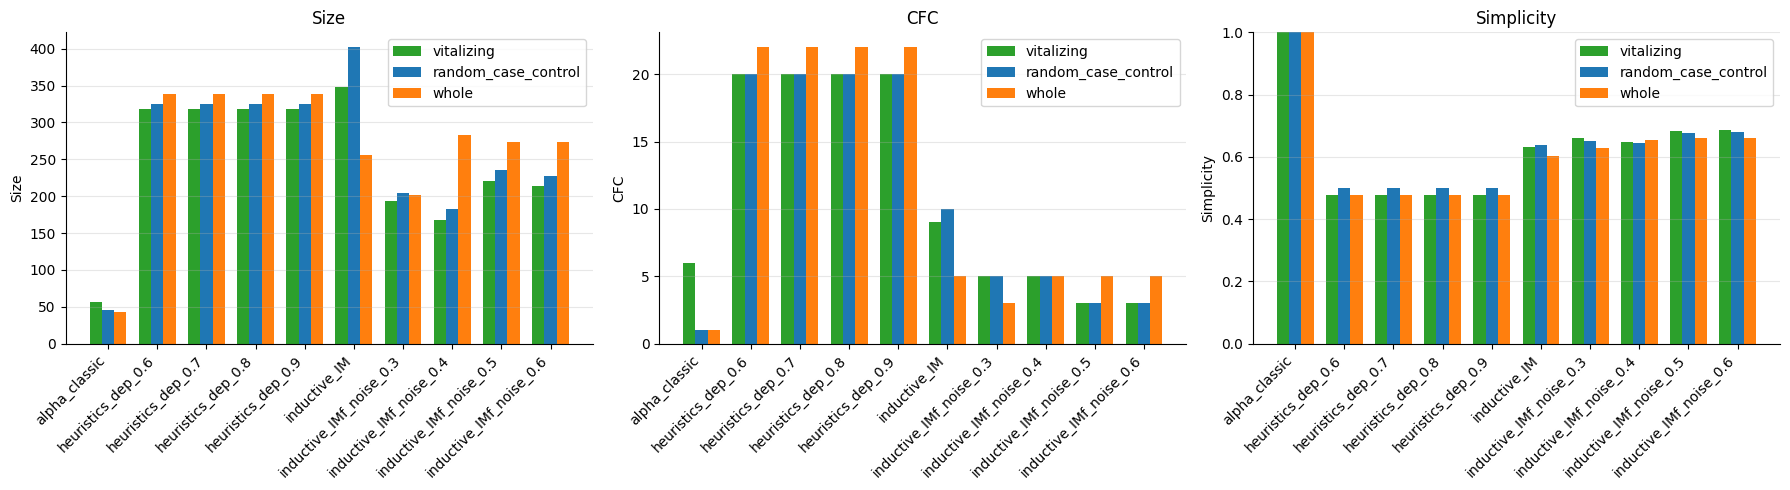

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\TradingAgents\clean_log_threshold_sensitivity.{png,pdf}


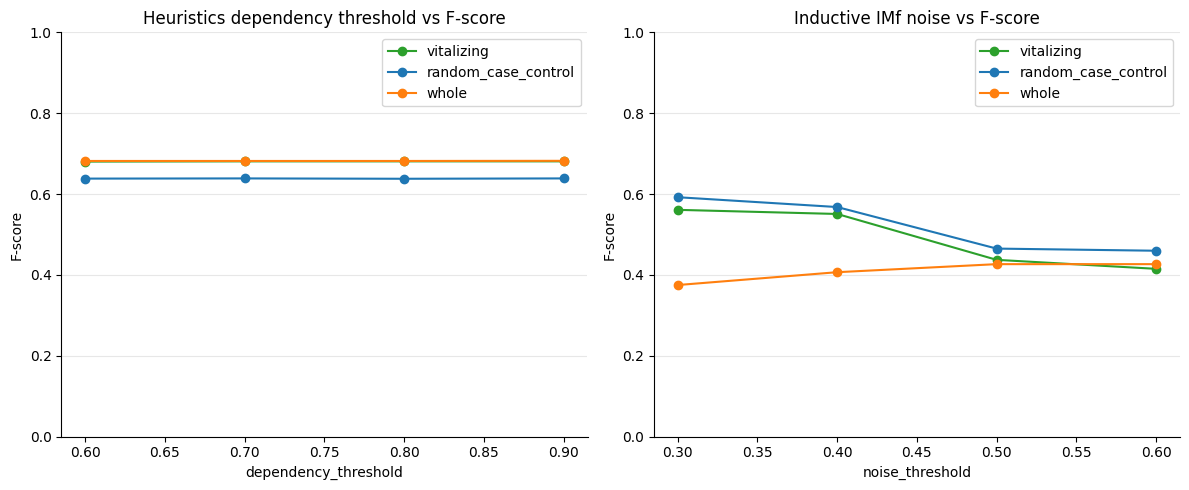

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\TradingAgents\clean_log_f_score_slopegraph.{png,pdf}


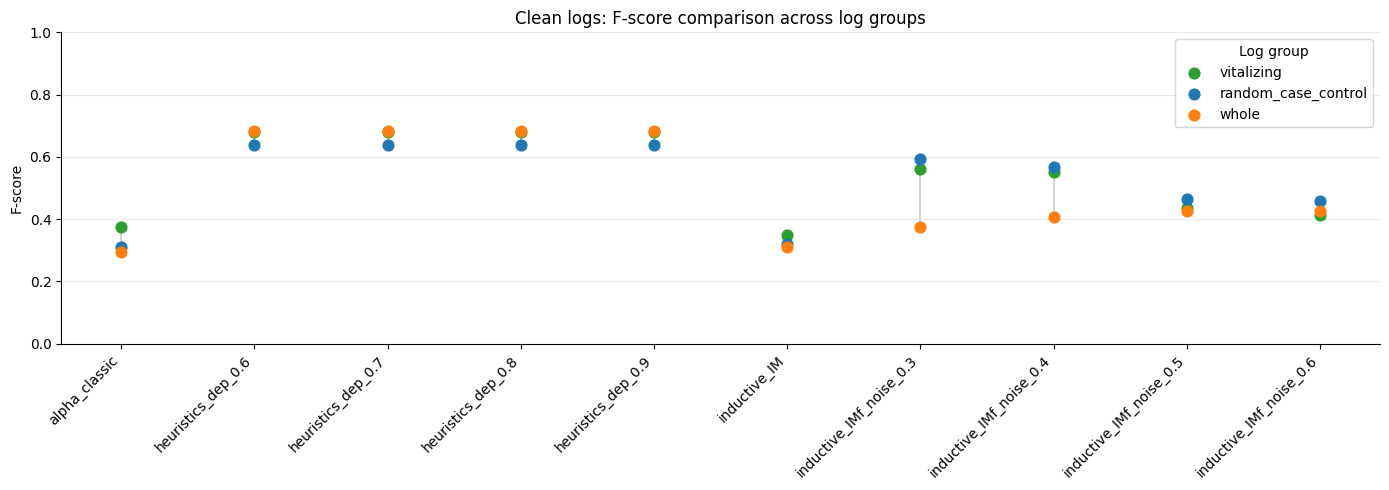

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.6  heuristics_dep_0.7  \
 log_name                                                                     
 random_case_control       0.311441            0.638163            0.638627   
 vitalizing                0.375486            0.680262            0.680839   
 whole                     0.293913            0.681796            0.681796   
 
 discovery_method     heuristics_dep_0.8  heuristics_dep_0.9  inductive_IM  \
 log_name                                                                    
 random_case_control            0.637777            0.638627      0.321241   
 vitalizing                     0.680839            0.680839      0.348241   
 whole                          0.681796            0.682148      0.309940   
 
 discovery_method     inductive_IMf_noise_0.3  inductive_IMf_noise_0.4  \
 log_name                                                                
 random_case_control                 0.59

In [10]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 94/94 [00:00<00:00, 526.91it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
          discovery_method  fitness_mean  fitness_std  fitness_cv  \
0            alpha_classic      0.618716     0.035750    0.057781   
1       heuristics_dep_0.6      0.793938     0.024549    0.030921   
2       heuristics_dep_0.7      0.794146     0.024392    0.030715   
3       heuristics_dep_0.8      0.793857     0.024517    0.030883   
4       heuristics_dep_0.9      0.794077     0.024355    0.030671   
5             inductive_IM      1.000000     0.000000    0.000000   
6  inductive_IMf_noise_0.3      0.943209     0.019199    0.020355   
7  inductive_IMf_noise_0.4      0.913047     0.017562    0.019234   
8  inductive_IMf_noise_0.5      0.909835     0.019031    0.020917   
9  inductive_IMf_noise_0.6      0.872818     0.017944    0.020559   

   precision_mean  precision_std  precision_cv  f_score_mean  f_score_std  \
0        0.196277       0.023156      0.117976   

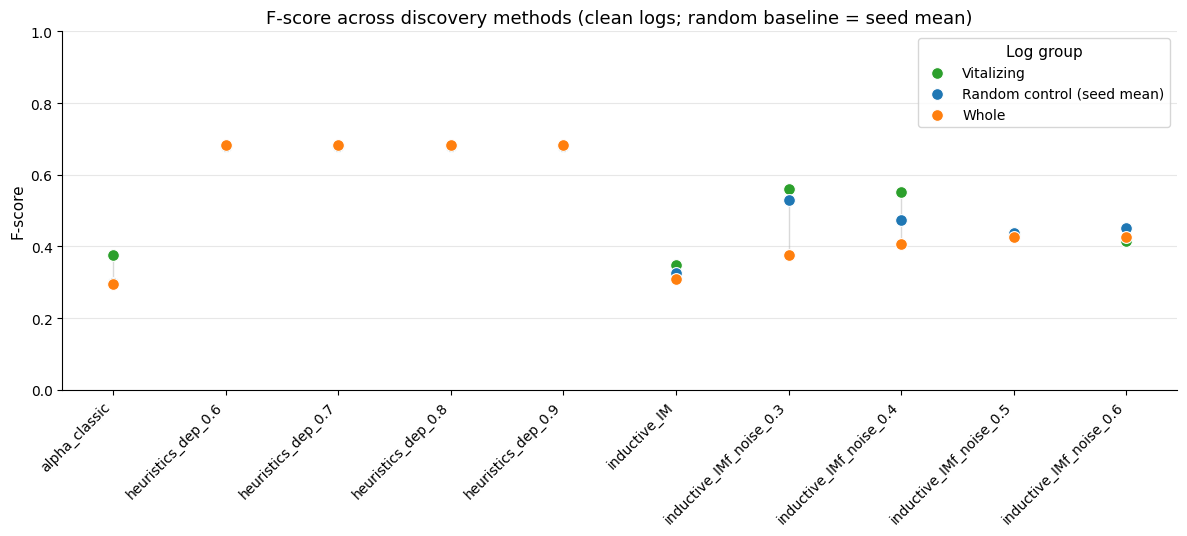

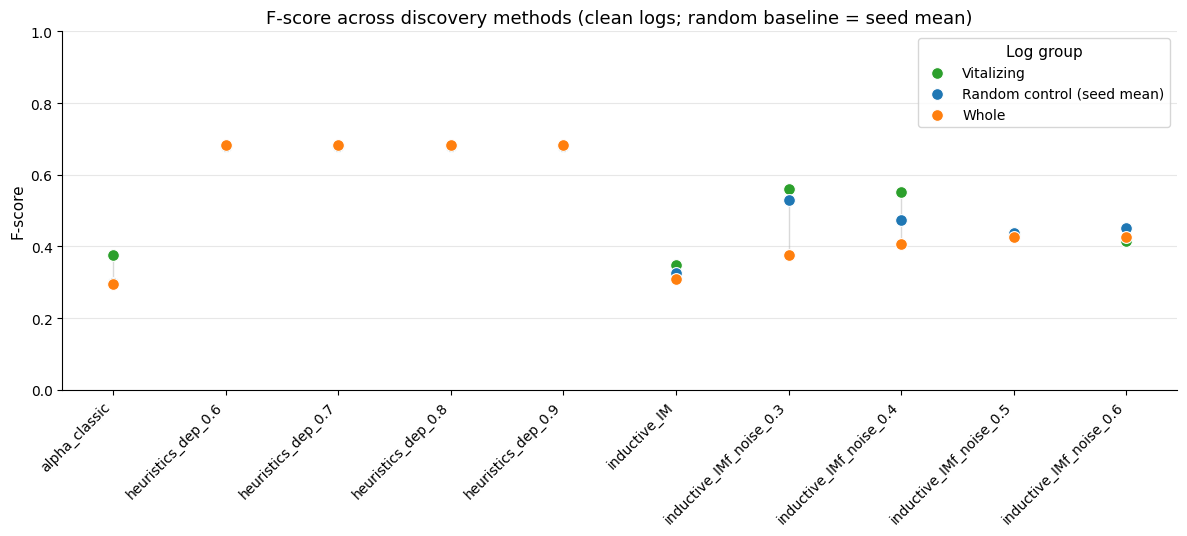

In [11]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)


## 12. Log complexity metrics (process-complexity / EPA)


In [ ]:
from functions.complexity_metrics import compute_log_complexity_table

log_complexity_similarity_table = compute_log_complexity_table(clean_log_groups_eventlog, cfg)
log_complexity_similarity_table
